1.Import dan Load data dari dataset

In [1]:
# Sel 1 (jalanin DULU)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Sel 2
df = pd.read_csv("dataset.csv")
df.head()

,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Nacionality,Mother's qualification,Father's qualification,Mother's occupation,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,8,5,2,1,1,1,13,10,6,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,6,1,11,1,1,1,1,3,4,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,5,1,1,1,22,27,10,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,8,2,15,1,1,1,23,27,6,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,12,1,3,0,1,1,22,28,10,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


In [2]:
df.info()
print (df['Target'].value_counts(normalize=True))

<class 'pandas.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 35 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Marital status                                  4424 non-null   int64  
 1   Application mode                                4424 non-null   int64  
 2   Application order                               4424 non-null   int64  
 3   Course                                          4424 non-null   int64  
 4   Daytime/evening attendance                      4424 non-null   int64  
 5   Previous qualification                          4424 non-null   int64  
 6   Nacionality                                     4424 non-null   int64  
 7   Mother's qualification                          4424 non-null   int64  
 8   Father's qualification                          4424 non-null   int64  
 9   Mother's occupation                             4424

Cek Grafik Distribusi Status Siswa

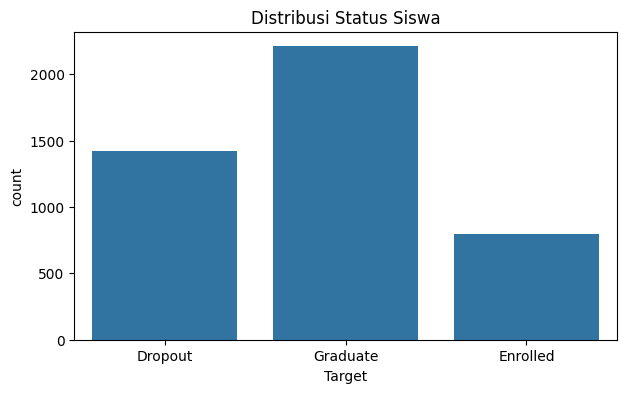

In [3]:
plt.figure(figsize=(7, 4))
sns.countplot(x='Target', data=df)
plt.title('Distribusi Status Siswa')
plt.show()

Grafik Nilai Semester 2 vs Status

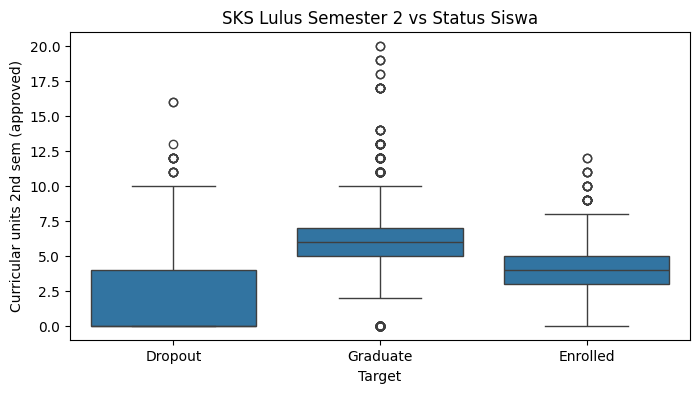

In [5]:
plt.figure(figsize=(8, 4))
sns.boxplot(x='Target', y='Curricular units 2nd sem (approved)', data=df)
plt.title('SKS Lulus Semester 2 vs Status Siswa')
plt.show()

Bayar UKT tepat waktu VS status

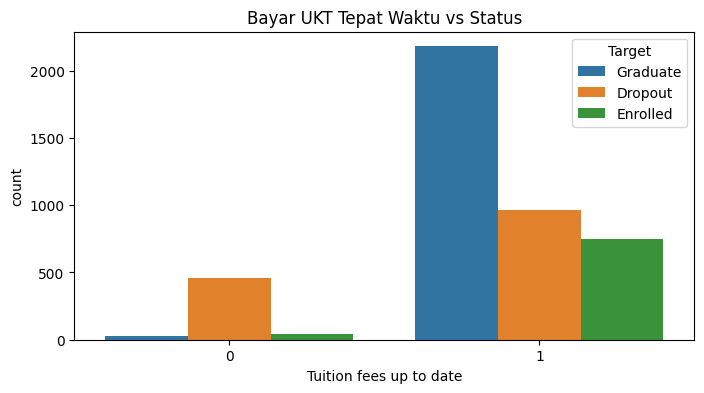

In [6]:
plt.figure(figsize=(8, 4))
sns.countplot(x='Tuition fees up to date', hue='Target', data=df)
plt.title('Bayar UKT Tepat Waktu vs Status')
plt.show()

Penerima Beasiswa vs Status

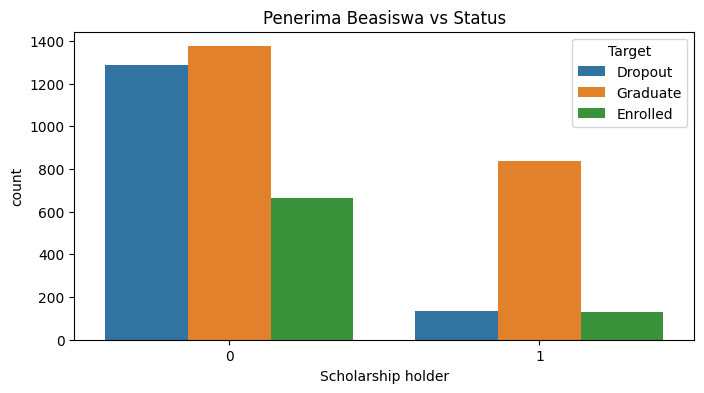

In [7]:
plt.figure(figsize=(8, 4))
sns.countplot(x='Scholarship holder', hue='Target', data=df)
plt.title('Penerima Beasiswa vs Status')
plt.show()

Pisahin X dan Y
kebanyakan kolom udah angka (liat dari head tadi semua angka). Tapi kita konfirmasi dulu — kalau ada kolom teks nyempil, perlu di-encode. Engineer nggak asumsi, tapi cek. 🎯

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# pisah fitur & target
X = df.drop(columns=['Target'])
y = df['Target']

# cek: X semua angka? (harusnya iya, dataset ini udah numerik)
print(X.dtypes.value_counts())
print("Kelas target:", y.unique())

int64      29
float64     5
Name: count, dtype: int64
Kelas target: <ArrowStringArray>
['Dropout', 'Graduate', 'Enrolled']
Length: 3, dtype: str


In [9]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report

# split (train dulu!)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# scaling (buat SVM)
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

# === Decision Tree (+ class_weight) ===
tree = DecisionTreeClassifier(max_depth=10, random_state=42, class_weight='balanced')
tree.fit(X_train, y_train)
print("Decision Tree:", accuracy_score(y_test, tree.predict(X_test)))

# === SVM (+ class_weight, pakai scaled) ===
svm = SVC(kernel='rbf', C=1, random_state=42, class_weight='balanced')
svm.fit(X_train_s, y_train)
print("SVM:", accuracy_score(y_test, svm.predict(X_test_s)))

# === Random Forest (+ class_weight) ===
rf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf.fit(X_train, y_train)
print("Random Forest:", accuracy_score(y_test, rf.predict(X_test)))

Decision Tree: 0.7048192771084337
SVM: 0.7341867469879518
Random Forest: 0.7725903614457831


In [10]:
from sklearn.metrics import classification_report, confusion_matrix

# Random Forest (pemenang) — analisis detail
pred_rf = rf.predict(X_test)

print("=== Random Forest — Classification Report ===")
print(classification_report(y_test, pred_rf))


print("=== Confusion Matrix ===")
print(confusion_matrix(y_test, pred_rf))
print("Urutan kelas:", rf.classes_)

=== Random Forest — Classification Report ===
              precision    recall  f1-score   support

     Dropout       0.80      0.79      0.80       441
    Enrolled       0.61      0.32      0.42       245
    Graduate       0.78      0.93      0.85       642

    accuracy                           0.77      1328
   macro avg       0.73      0.68      0.69      1328
weighted avg       0.76      0.77      0.75      1328

=== Confusion Matrix ===
[[350  25  66]
 [ 65  79 101]
 [ 20  25 597]]
Urutan kelas: ['Dropout' 'Enrolled' 'Graduate']


In [11]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5]
}

grid = GridSearchCV(
    RandomForestClassifier(random_state=42, class_weight='balanced'),
    param_grid,
    cv=3,
    scoring='f1_macro'      # fokus seimbang semua kelas
)
grid.fit(X_train, y_train)

print("Kombinasi terbaik:", grid.best_params_)
print("Skor terbaik:", grid.best_score_)

Kombinasi terbaik: {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 100}
Skor terbaik: 0.7105994370693188


In [12]:
from sklearn.metrics import classification_report

# pakai model terbaik dari GridSearch
best_rf = grid.best_estimator_
pred_best = best_rf.predict(X_test)

print("=== Random Forest TERBAIK (setelah tuning) ===")
print(classification_report(y_test, pred_best))

=== Random Forest TERBAIK (setelah tuning) ===
              precision    recall  f1-score   support

     Dropout       0.83      0.73      0.77       441
    Enrolled       0.49      0.54      0.51       245
    Graduate       0.82      0.86      0.84       642

    accuracy                           0.76      1328
   macro avg       0.71      0.71      0.71      1328
weighted avg       0.76      0.76      0.76      1328



In [13]:
# ambil feature importance dari Random Forest
importance = pd.DataFrame({
    'fitur': X.columns,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

# 10 faktor teratas
print(importance.head(10))

                                     fitur  importance
28     Curricular units 2nd sem (approved)    0.119015
29        Curricular units 2nd sem (grade)    0.097525
22     Curricular units 1st sem (approved)    0.080876
23        Curricular units 1st sem (grade)    0.075435
27  Curricular units 2nd sem (evaluations)    0.056586
17                       Age at enrollment    0.048354
21  Curricular units 1st sem (evaluations)    0.045398
3                                   Course    0.039681
10                     Father's occupation    0.037586
9                      Mother's occupation    0.033779


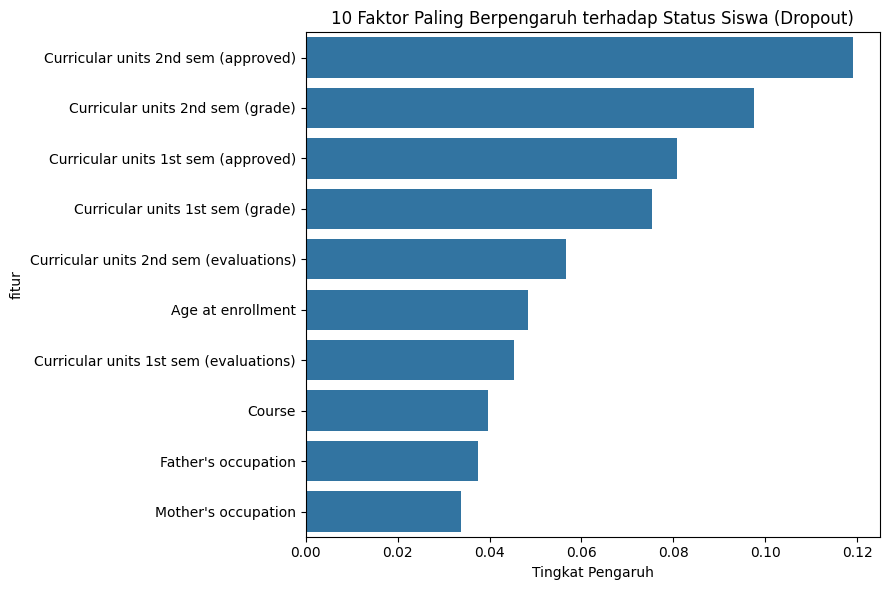

In [14]:
plt.figure(figsize=(9, 6))
sns.barplot(x='importance', y='fitur', data=importance.head(10))
plt.title('10 Faktor Paling Berpengaruh terhadap Status Siswa (Dropout)')
plt.xlabel('Tingkat Pengaruh')
plt.tight_layout()
plt.show()

### 🔎 Insight Feature Importance

Faktor penentu dropout (Random Forest):
1. SKS lulus semester 2 (12%) — akademik
2. Nilai semester 2 (10%) — akademik
3. SKS lulus semester 1 (8%) — akademik
4. Nilai semester 1 (7.5%) — akademik

> **Temuan kunci:** Performa akademik semester awal adalah prediktor TERKUAT dropout — 4 faktor teratas semuanya akademik. Konsisten dengan temuan EDA.
>
> **Rekomendasi:** Sistem peringatan dini berbasis nilai/SKS semester 1 untuk intervensi cepat siswa berisiko.